In [1]:
import sys
path_to_pip_installs = "/tmp/test_env"
if path_to_pip_installs not in sys.path:
    sys.path.insert(0, path_to_pip_installs)


In [48]:
import math
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from losses import loss_dict

In [5]:
results = pd.read_csv("loss_results_experiment.csv")
results

,Dice_Loss,Case,Data_Contrast,Target_Contrast,Split,LNCC_Monai,MI_Monai,SSIM_Monai,NMI_Loss,MIND_SSC_Loss,SSD_Loss,Blurred_SSD_Loss,Squared_LNCC_Loss,New_LNCC_Loss,PSNR_Loss
0,0.859070,Orginal,T1_mapping_fl2d,DIXON,test,-0.3778,-0.0062,0.6388,-1.4001,0.1071,0.0542,0.0233,0.4877,0.3460,18.5719
1,0.849322,Orginal,T1_mapping_fl2d,DIXON,test,-0.3701,-0.0074,0.6235,-1.4264,0.1087,0.0487,0.0167,0.5114,0.3468,18.8986
2,0.854321,Orginal,T1_mapping_fl2d,DIXON,test,-0.3731,-0.0061,0.6092,-1.3186,0.1159,0.0452,0.0142,0.5063,0.3344,18.5786
3,0.865147,Orginal,T1_mapping_fl2d,DIXON,test,-0.3634,-0.0031,0.6479,-1.2752,0.1197,0.0527,0.0199,0.5347,0.3624,17.7982
4,0.893525,Orginal,T1_mapping_fl2d,DIXON,test,-0.3659,-0.0010,0.6537,-1.4528,0.1152,0.0585,0.0249,0.5294,0.3845,17.2904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3035,0.756926,Affine_DIXON,DIXON,DIXON,test,-0.2894,-0.0006,0.7612,-1.1844,0.2049,0.0386,0.0111,0.7936,0.5644,15.3294
3036,0.499008,Affine_DIXON,DIXON,DIXON,test,-0.2238,-0.0002,0.8147,-1.2418,0.2513,0.0712,0.0389,0.8393,0.7641,12.4508
3037,0.661972,Affine_DIXON,DIXON,DIXON,test,-0.2536,-0.0002,0.7726,-1.2676,0.2220,0.0459,0.0164,0.8104,0.6490,14.6381
3038,0.457372,Affine_DIXON,DIXON,DIXON,test,-0.2632,-0.0000,0.8163,-1.0000,0.2318,0.0607,0.0306,0.8128,0.7333,13.0346


Error fitting line for NMI_Loss: SVD did not converge in Linear Least Squares ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value



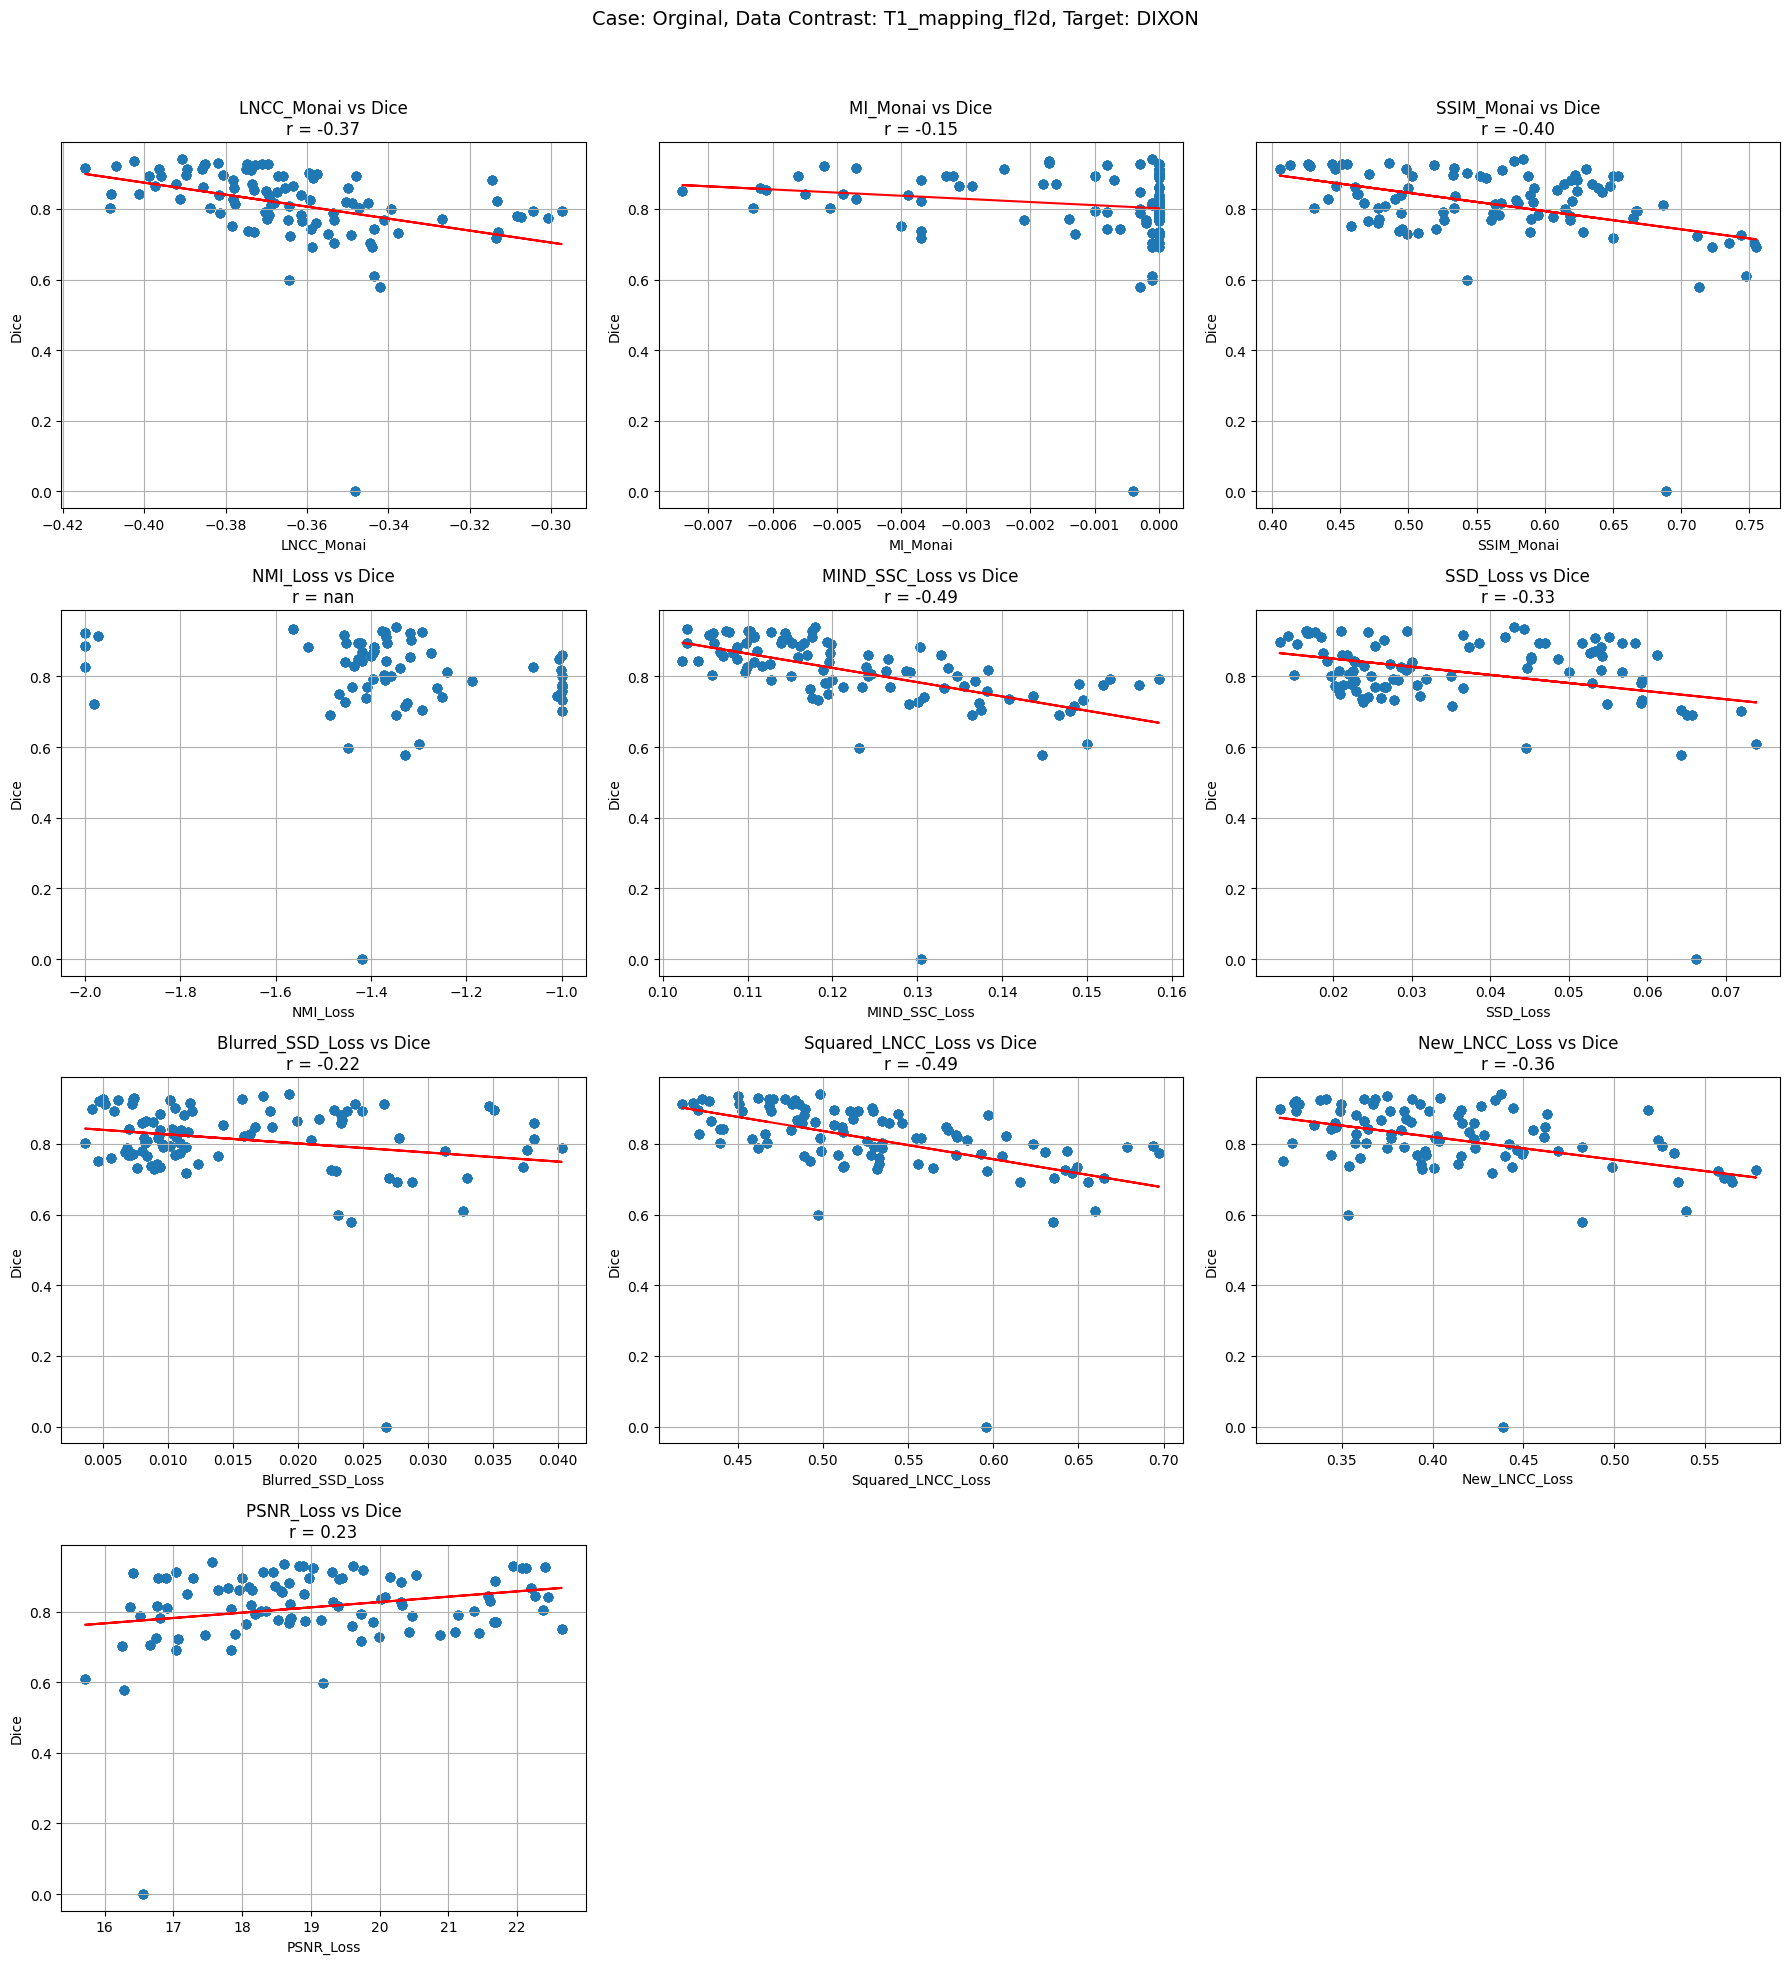

In [29]:
def visualize_loss_correlation(results, loss_name, case, data_contrast, target_contrast):
    subset = results[(results['Case'] == case) & 
                     (results['Data_Contrast'] == data_contrast) & 
                     (results['Target_Contrast'] == target_contrast)]
    
    loss_values = subset[loss_name].values
    dice_scores = subset['Dice_Loss'].values
    
    correlation, _ = pearsonr(loss_values, dice_scores)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(loss_values, dice_scores)
    plt.title(f'Correlation between {loss_name} and DICE\n'
              f'Case: {case}, Data Contrast: {data_contrast}\n'
              f'Pearson Correlation: {correlation:.2f}')
    # draw correlation line
    m, b = np.polyfit(loss_values, dice_scores, 1)
    plt.plot(loss_values, m*loss_values + b, color='red')
    plt.xlabel(loss_name)
    plt.ylabel('Dice')
    plt.grid()
    plt.show()

def visualize_loss_correlations(results, loss_names, case, data_contrast, target_contrast):
    """
    Visualize correlation between multiple loss metrics and Dice Loss.

    Parameters
    ----------
    results : pd.DataFrame
        DataFrame containing results.
    loss_names : list of str
        List of loss metric column names.
    case : str
        Case filter.
    data_contrast : str
        Data contrast filter.
    target_contrast : str
        Target contrast filter.
    """
    
    # Filter the DataFrame
    subset = results[
        (results['Case'] == case) & 
        (results['Data_Contrast'] == data_contrast) & 
        (results['Target_Contrast'] == target_contrast)
    ]
    
    n_losses = len(loss_names)
    n_cols = min(3, n_losses)  # up to 3 plots per row
    n_rows = math.ceil(n_losses / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    axes = np.array(axes).reshape(-1)  # flatten in case of single row/column
    
    for i, loss_name in enumerate(loss_names):
        ax = axes[i]
        loss_values = subset[loss_name].values
        dice_scores = subset['Dice_Loss'].values

        # Compute Pearson correlation
        correlation, _ = pearsonr(loss_values, dice_scores)
        
        # Scatter plot
        ax.scatter(loss_values, dice_scores)
        ax.set_title(f'{loss_name} vs Dice\nr = {correlation:.2f}', fontsize=12)
        ax.set_xlabel(loss_name)
        ax.set_ylabel('Dice')
        ax.grid(True)

        # Add regression line
        try:
            m, b = np.polyfit(loss_values, dice_scores, 1)
            ax.plot(loss_values, m*loss_values + b, color='red')
        except Exception as e:
            print(f"Error fitting line for {loss_name}: {e}")

    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'Case: {case}, Data Contrast: {data_contrast}, Target: {target_contrast}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


visualize_loss_correlations(results, list(loss_dict.keys()), 'Orginal', 'T1_mapping_fl2d', 'DIXON')

Error fitting line for NMI_Loss: SVD did not converge in Linear Least Squares ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value



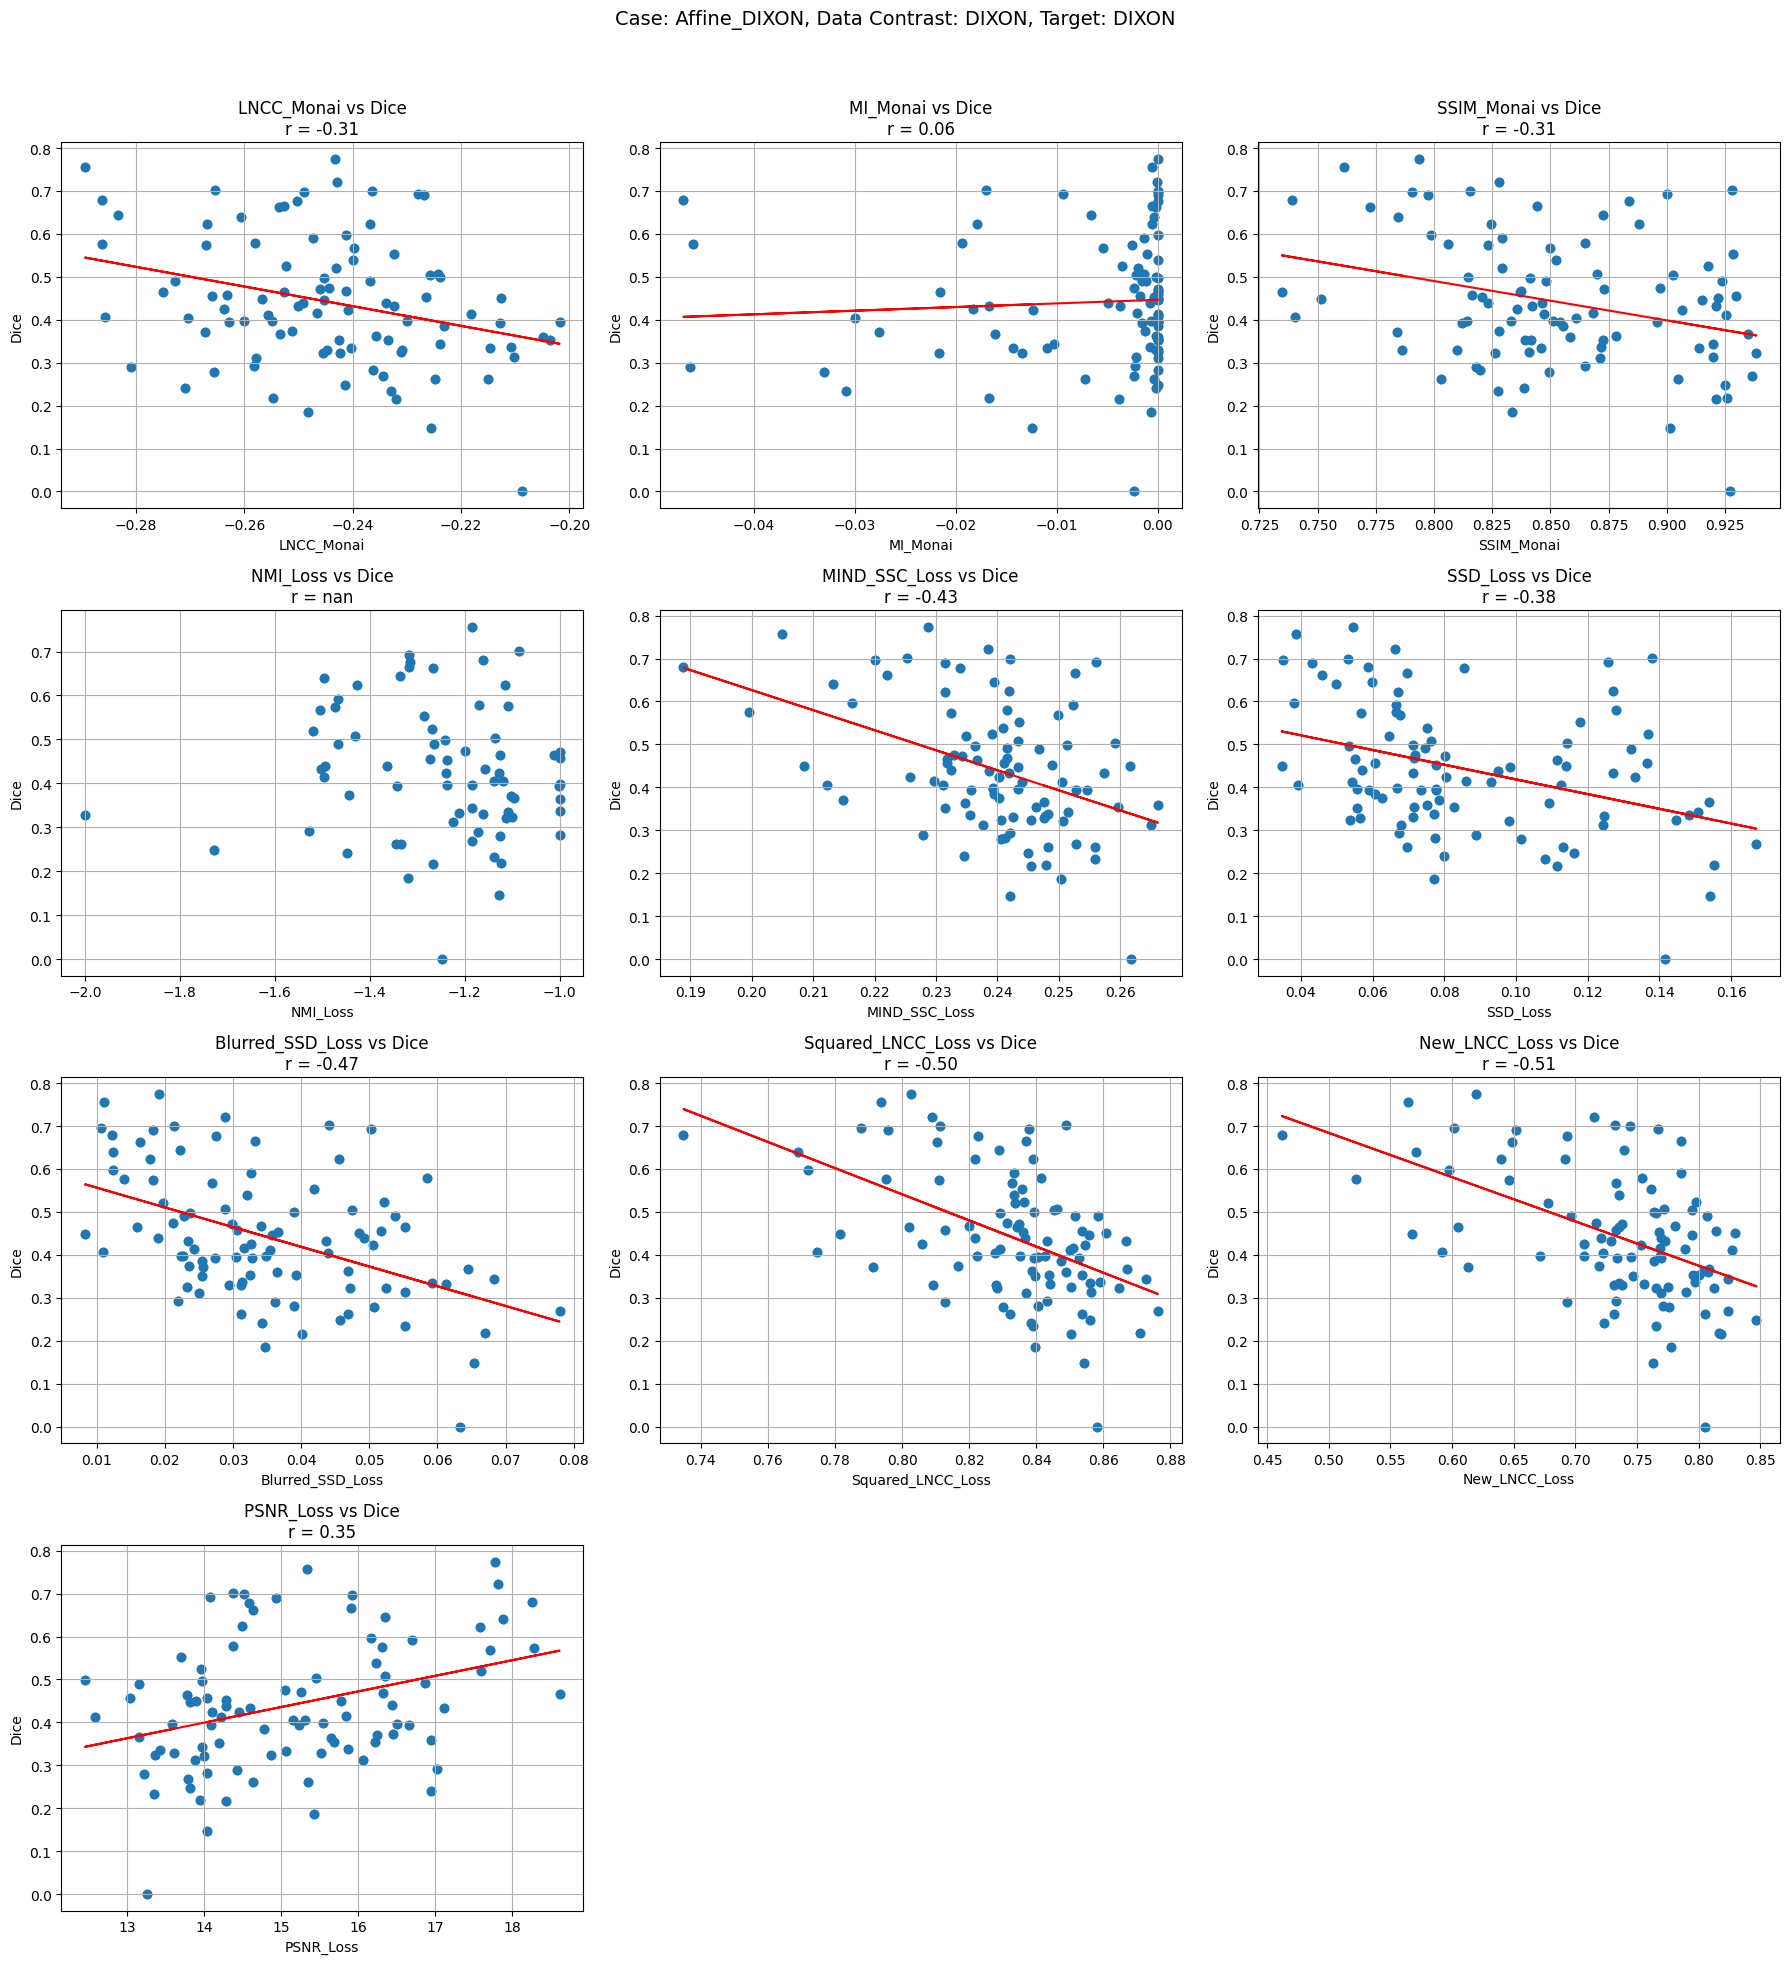

In [30]:
visualize_loss_correlations(results, list(loss_dict.keys()), 'Affine_DIXON', 'DIXON', 'DIXON')

## Visualize one image

In [ ]:
from transformations import apply_specific_affine_to_numpy_batch


In [40]:
data_dixon = np.load("/home/students/studweilc1/MU-Diff/data/my_data3/test/DIXON.npy")
data_dixon_masks = np.load("/home/students/studweilc1/MU-Diff/data/my_data3/test/DIXON_masks.npy")
data_t1 = np.load("/home/students/studweilc1/MU-Diff/data/transformed_data/test/T1_mapping_fl2d.npy")
data_t1_masks = np.load("/home/students/studweilc1/MU-Diff/data/transformed_data/test/T1_mapping_fl2d_masks.npy")

In [41]:
dixon_img = data_dixon[0:1]
dixon_mask = data_dixon_masks[0:1]
t1_img = data_t1[0]
t1_mask = data_t1_masks[0]

In [42]:
dixon_t, dixon_mask_t = apply_specific_affine_to_numpy_batch(dixon_img, dixon_mask, angle_deg=30)

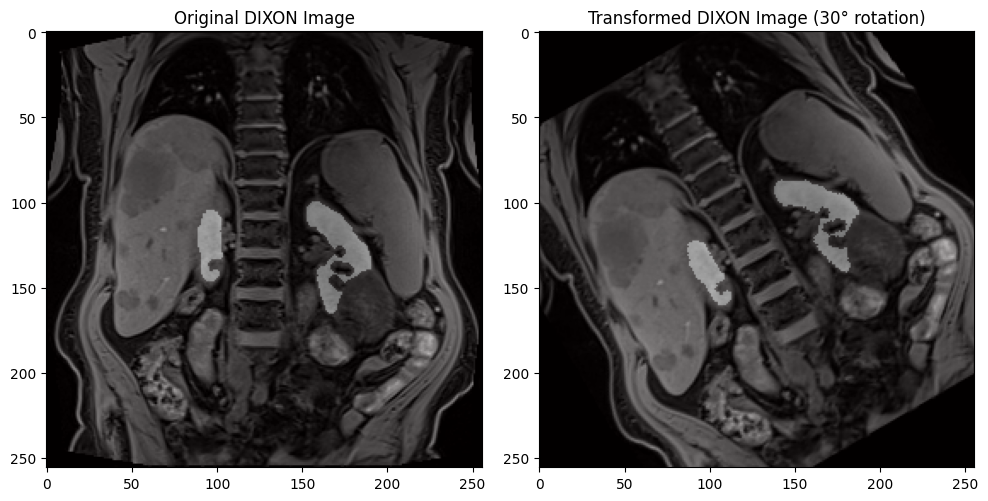

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(dixon_img[0, :, :], cmap='gray')
ax[0].imshow(dixon_mask[0, :, :], cmap='hot', alpha=0.3)
ax[0].set_title('Original DIXON Image')
ax[1].imshow(dixon_t[0, :, :], cmap='gray')
ax[1].imshow(dixon_mask_t[0, :, :], cmap='hot', alpha=0.3)
ax[1].set_title('Transformed DIXON Image (30° rotation)')
plt.tight_layout()

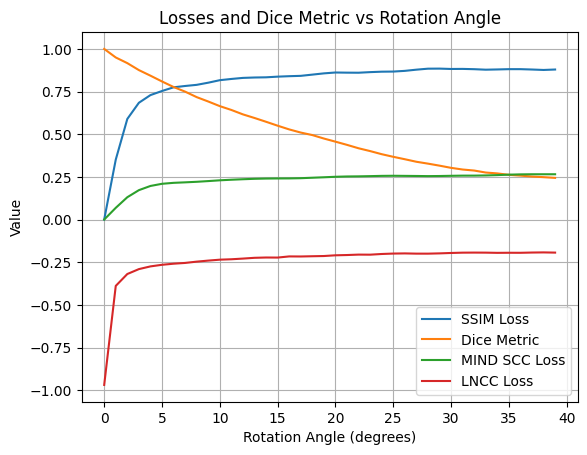

In [61]:
from losses import SSIM_loss_function, dice_metric, MINDSSC_loss_function, LNCC_loss_function
dixon_img = data_dixon[1:2]
dixon_mask = data_dixon_masks[1:2]

ssim_values = []
mind_scc_values = []
lncc_values = []
dice_values = []
for degree in range(0, 40, 1):
    dixon_t, dixon_mask_t = apply_specific_affine_to_numpy_batch(dixon_img, dixon_mask, angle_deg=degree)
    ssim_value = SSIM_loss_function(torch.from_numpy(dixon_img).unsqueeze(0), torch.from_numpy(dixon_t).unsqueeze(0))
    dice_value = dice_metric(torch.from_numpy(dixon_mask).unsqueeze(0), torch.from_numpy(dixon_mask_t).unsqueeze(0))
    mind_scc_value = MINDSSC_loss_function(torch.from_numpy(dixon_img).unsqueeze(0), torch.from_numpy(dixon_t).unsqueeze(0))
    lncc_value = LNCC_loss_function(torch.from_numpy(dixon_img).unsqueeze(0), torch.from_numpy(dixon_t).unsqueeze(0))
    ssim_values.append(ssim_value.item())
    dice_values.append(dice_value.item())
    mind_scc_values.append(mind_scc_value.item())
    lncc_values.append(lncc_value.item())

plt.plot(range(0, 40, 1), ssim_values, label='SSIM Loss')
plt.plot(range(0, 40, 1), dice_values, label='Dice Metric')
plt.plot(range(0, 40, 1), mind_scc_values, label='MIND SCC Loss')
plt.plot(range(0, 40, 1), lncc_values, label='LNCC Loss')
plt.xlabel('Rotation Angle (degrees)')
plt.ylabel('Value')
plt.title('Losses and Dice Metric vs Rotation Angle')
plt.legend()
plt.grid()
plt.show()


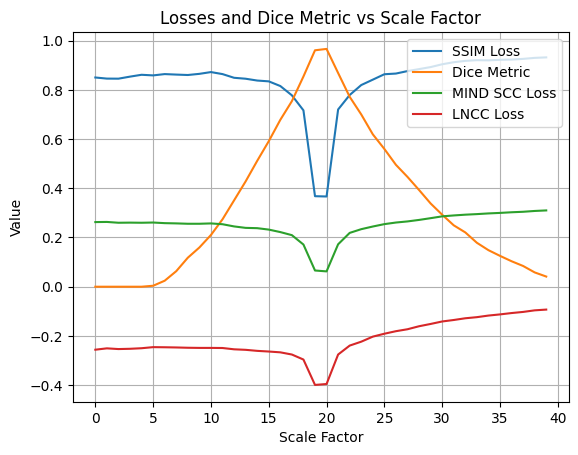

In [59]:
from losses import SSIM_loss_function, dice_metric, MINDSSC_loss_function, LNCC_loss_function
dixon_img = data_dixon[0:1]
dixon_mask = data_dixon_masks[0:1]

ssim_values = []
mind_scc_values = []
lncc_values = []
dice_values = []
for scale in np.linspace(0.5, 1.5, 40):
    dixon_t, dixon_mask_t = apply_specific_affine_to_numpy_batch(dixon_img, dixon_mask, angle_deg=0, scale=scale)
    ssim_value = SSIM_loss_function(torch.from_numpy(dixon_img).unsqueeze(0), torch.from_numpy(dixon_t).unsqueeze(0))
    dice_value = dice_metric(torch.from_numpy(dixon_mask).unsqueeze(0), torch.from_numpy(dixon_mask_t).unsqueeze(0))
    mind_scc_value = MINDSSC_loss_function(torch.from_numpy(dixon_img).unsqueeze(0), torch.from_numpy(dixon_t).unsqueeze(0))
    lncc_value = LNCC_loss_function(torch.from_numpy(dixon_img).unsqueeze(0), torch.from_numpy(dixon_t).unsqueeze(0))
    ssim_values.append(ssim_value.item())
    dice_values.append(dice_value.item())
    mind_scc_values.append(mind_scc_value.item())
    lncc_values.append(lncc_value.item())

plt.plot(range(0, 40, 1), ssim_values, label='SSIM Loss')
plt.plot(range(0, 40, 1), dice_values, label='Dice Metric')
plt.plot(range(0, 40, 1), mind_scc_values, label='MIND SCC Loss')
plt.plot(range(0, 40, 1), lncc_values, label='LNCC Loss')
plt.xlabel('Scale Factor')
plt.ylabel('Value')
plt.title('Losses and Dice Metric vs Scale Factor')
plt.legend()
plt.grid()
plt.show()


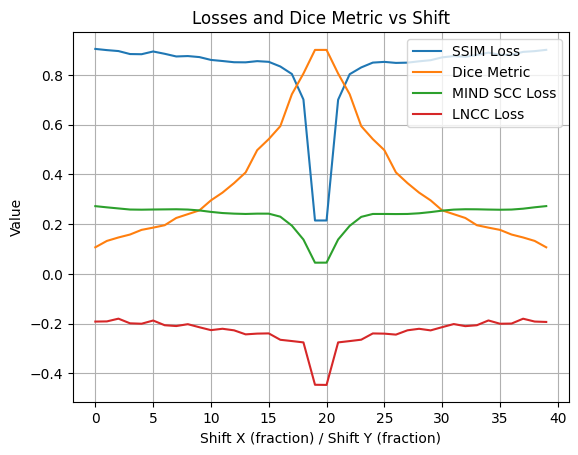

In [ ]:
from losses import SSIM_loss_function, dice_metric, MINDSSC_loss_function, LNCC_loss_function
dixon_img = data_dixon[0:1]
dixon_mask = data_dixon_masks[0:1]

ssim_values = []
mind_scc_values = []
lncc_values = []
dice_values = []
for shift_x, shift_y in zip(np.linspace(-0.2, 0.2, 40), np.linspace(-0.2, 0.2, 40)):
    dixon_t, dixon_mask_t = apply_specific_affine_to_numpy_batch(dixon_img, dixon_mask, shift_x_frac=shift_x, shift_y_frac=shift_y)
    ssim_value = SSIM_loss_function(torch.from_numpy(dixon_img).unsqueeze(0), torch.from_numpy(dixon_t).unsqueeze(0))
    dice_value = dice_metric(torch.from_numpy(dixon_mask).unsqueeze(0), torch.from_numpy(dixon_mask_t).unsqueeze(0))
    mind_scc_value = MINDSSC_loss_function(torch.from_numpy(dixon_img).unsqueeze(0), torch.from_numpy(dixon_t).unsqueeze(0))
    lncc_value = LNCC_loss_function(torch.from_numpy(dixon_img).unsqueeze(0), torch.from_numpy(dixon_t).unsqueeze(0))
    ssim_values.append(ssim_value.item())
    dice_values.append(dice_value.item())
    mind_scc_values.append(mind_scc_value.item())
    lncc_values.append(lncc_value.item())

plt.plot(range(0, 40, 1), ssim_values, label='SSIM Loss')
plt.plot(range(0, 40, 1), dice_values, label='Dice Metric')
plt.plot(range(0, 40, 1), mind_scc_values, label='MIND SCC Loss')
plt.plot(range(0, 40, 1), lncc_values, label='LNCC Loss')
plt.xlabel('Shift X (fraction) / Shift Y (fraction)')
plt.ylabel('Value')
plt.title('Losses and Dice Metric vs Shift')
plt.legend()
plt.grid()
plt.show()
